# Fast Agent - Build a SQL Agent fast!

<img src="./assets/LC_L1_top.png" align="left" width="500">

## Setup

Load and/or check for needed environmental variables

In [49]:
from dotenv import load_dotenv
from env_utils import doublecheck_env, doublecheck_pkgs

# Load environment variables from .env
load_dotenv()

# Check and print results
doublecheck_env(".env")  # check environmental variables
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)   # check packages

OPENAI_API_KEY=****23oA
GPT_NANO=****nano
LANGSMITH_API_KEY=****a636
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=****ials
GEMINI_API_KEY=****FD8k
Python 3.12.8 satisfies requires-python: >=3.11,<3.14
package                | required | installed | status | path                                                                            
---------------------- | -------- | --------- | ------ | --------------------------------------------------------------------------------
langgraph              | >=1.0.0  | 1.0.1     | ✅ OK   | …essentials/lca-langchainV1-essentials/python/.venv/lib/python3.12/site-packages
langchain              | >=1.0.0  | 1.0.2     | ✅ OK   | …essentials/lca-langchainV1-essentials/python/.venv/lib/python3.12/site-packages
langchain-core         | >=1.0.0  | 1.0.1     | ✅ OK   | …essentials/lca-langchainV1-essentials/python/.venv/lib/python3.12/site-packages
langchain-openai       | >=1.0.0  | 1.0.1     | ✅ OK   | …essentials/lca-langchainV1-essentials/python/.venv/lib/

In [50]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

Define the runtime context to provide the agent and tools with access to the database.

In [51]:
from dataclasses import dataclass

from langchain_community.utilities import SQLDatabase


# define context structure to support dependency injection
@dataclass
class RuntimeContext:
    db: SQLDatabase

In [52]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [53]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go!  You can choose many agents from our [integrations](https://docs.langchain.com/oss/python/integrations/providers) list. 

In [56]:
from langchain.agents import create_agent

agent = create_agent(
    model="openai:gpt-5-nano",
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Here's a display of the agent ReAct Loop.

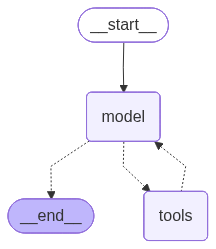

In [55]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [57]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_zwkf4dho352acewNf0VDRQNX)
 Call ID: call_zwkf4dho352acewNf0VDRQNX
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name ASC LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',)]
================================== Ai Message ==================================

Here are the first 5 tables (excluding SQLite internal tables), in alphabetical order:

- Album
- Artist
- Customer
- Employee
- Genre

If you’d like me to show all tables (there may be more), say "show all" and I’ll fetch the complete list.


In [58]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_4GyyDJTRgQjlMgCxDgMTSKb4)
 Call ID: call_4GyyDJTRgQjlMgCxDgMTSKb4
  Args:
    query: SELECT name AS table_name
FROM sqlite_master
WHERE type='table'
  AND name NOT LIKE 'sqlite_%'
ORDER BY name ASC
LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_wBN1eh7SfxokOyjuFs1FVNsA)
 Call ID: call_wBN1eh7SfxokOyjuFs1FVNsA
  Args:
    query: SELECT table_name, cnt FROM (
  SELECT 'Album' AS table_name, COUNT(*) AS cnt FROM Album
  UNION ALL
  SELECT 'Artist', COUNT(*) FROM Artist
  UNION ALL
  SELECT 'Customer', COUNT(*) FR

In [ ]:
question = "Which Genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

**Create your own query here!**  Add some questions of your own.

In [ ]:
question = "TRY YOUR OWN QUERY HERE"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

### Let's try this Studio